# **Task 6: K-Nearest Neighbors (KNN) Classification**
- ## **Objective: Understand and implement KNN for classification problems.**
- # **Tools:  Scikit-learn, Pandas, Matplotlib**

### **1.Choose a classification dataset and normalize features.**

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Load dataset
df = pd.read_csv("Iris.csv")
# Drop ID column if exists
df.drop(columns=['Id'], inplace=True)
# Separate features and target
X = df.drop('Species', axis=1)
y = df['Species']
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Display first 5 rows of normalized features
print(pd.DataFrame(X_scaled, columns=X.columns).head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      -0.900681      1.032057      -1.341272     -1.312977
1      -1.143017     -0.124958      -1.341272     -1.312977
2      -1.385353      0.337848      -1.398138     -1.312977
3      -1.506521      0.106445      -1.284407     -1.312977
4      -1.021849      1.263460      -1.341272     -1.312977


### **2.Use KNeighborsClassifier from sklearn.**

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize the model with k=3
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Show predictions
print("Predictions for first 10 test samples:\n", y_pred[:10])

Predictions for first 10 test samples:
 ['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor']


### **3.Experiment with different values of K.**

In [3]:
from sklearn.metrics import accuracy_score

print("K-value\tAccuracy")
for k in range(1, 11):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    print(f"{k}\t{acc:.2f}")

K-value	Accuracy
1	0.98
2	0.98
3	1.00
4	0.98
5	1.00
6	1.00
7	1.00
8	1.00
9	1.00
10	1.00


### **4.Evaluate model using accuracy, confusion matrix.**

In [4]:
from sklearn.metrics import confusion_matrix, classification_report

# Using k=3 as before
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



### **5.Visualize decision boundaries.**

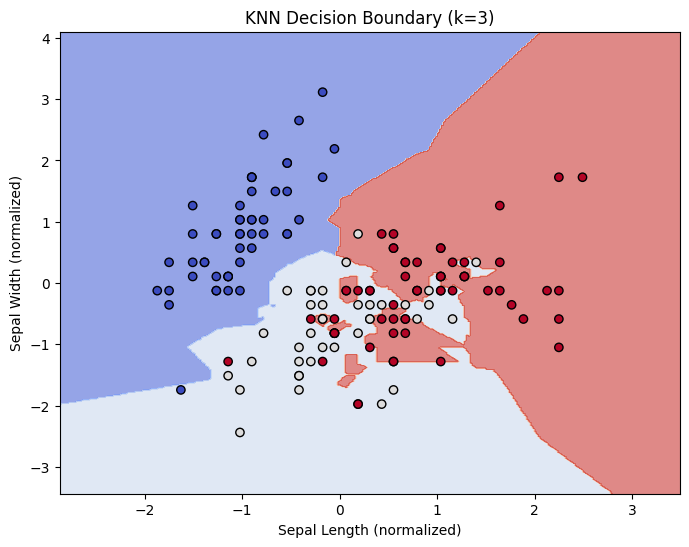

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Reduce to 2D for visualization
X_vis = X_scaled[:, :2]  # Use first 2 features
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vis, y, test_size=0.3, random_state=42)

# Encode class labels to integers for visualization
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_v)
y_enc = le.transform(y)

# Train KNN
knn_vis = KNeighborsClassifier(n_neighbors=3)
knn_vis.fit(X_train_v, y_train_enc)

# Meshgrid
h = 0.02
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on meshgrid points and reshape for contourf
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_enc, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel("Sepal Length (normalized)")
plt.ylabel("Sepal Width (normalized)")
plt.title("KNN Decision Boundary (k=3)")
plt.show()